lokale csv 02Apple_Offline.csv wird geladen...
1 01.01.2019 0.533772
2 01.02.2019 0.506205
3 01.03.2019 0.479701
4 01.04.2019 0.43889
5 01.05.2019 0.398695
6 01.06.2019 0.482465
7 01.07.2019 0.414841
8 01.08.2019 0.401148
9 01.09.2019 0.404933
10 01.10.2019 0.370875
11 01.11.2019 0.325599
12 01.12.2019 0.314376
13 01.01.2020 0.276496
14 01.02.2020 0.269052
15 01.03.2020 0.277263
16 01.04.2020 0.3439
17 01.05.2020 0.286605
18 01.06.2020 0.25672
19 01.07.2020 0.226924
20 01.08.2020 0.189616
21 01.09.2020 0.153668
22 01.10.2020 0.176549
23 01.11.2020 0.189566
24 01.12.2020 0.167728
25 01.01.2021 0.159057
26 01.02.2021 0.153449
27 01.03.2021 0.160833
28 01.04.2021 0.167097
29 01.05.2021 0.155069
30 01.06.2021 0.165095
31 01.07.2021 0.149472
32 01.08.2021 0.140998
33 01.09.2021 0.134334
34 01.10.2021 0.14362


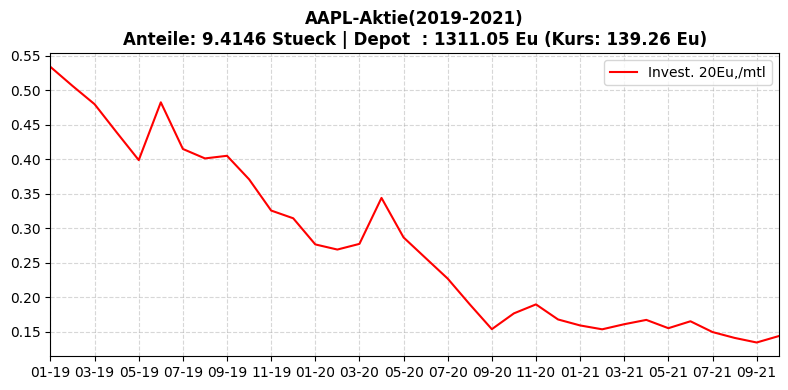

In [1]:
# AAPL_Beispiel.py  Übungsbeispiel 50Zeilen Aktiensparen zwischen 2019 und 2021
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime
import os
# %matplotlib widget
csv_Nam ="02Apple_Offline.csv"  # geht von 2015 bis 2026
if os.path.exists(csv_Nam):
   print(f"lokale csv {csv_Nam} wird geladen...")
   df_csv = pd.read_csv(csv_Nam)
   # Apple-Ticker-Preise aus CSV-Datei in Pandas-DataFrame laden
   df_csv['Date'] = pd.to_datetime(df_csv['Date'])
   # Werte in Spalte Date in ein standardisiertes Datumsformat umwandeln.
   df = df_csv.sort_values('Date').reset_index(drop=True)
   # Daten chronologisch nach Datum sortieren, Zeilennummern neu durchnummerieren.
   df.set_index('Date', inplace=True)
   # Alle Elemente werden ohne Kopier-Zwischenschritt per Datum indentifiziert
df_aktiensparen = df.loc['2019-01-01':'2021-10-01'].copy()
# Erstellen einer Teil-Kopie direkt über den Datums-Index
df_monthly = df_aktiensparen.resample("MS").first()
# Nach monatlichem Zusammenfassen der erfassten Monats-Ersttage(Anfaenge)
df_monthly = df_monthly.dropna(subset=["Price"])
# NaN(NotANumber) Elemente mit Defekt in Spalte "Price" aus Datei streichen
investment_per_month = 20
raten_plan = []
raten_nr = 0
for date, row in df_monthly.iterrows():
    # Paare (row-Index,row-Inhalt), letzteres als pd.series  
    price = row["Price"]
    # Inhalt der Spalte "Price" in der pd.series row
    units = investment_per_month / price
    # im aktuellen Monat moegl. Anteile
    datum = date.strftime("%d.%m.%Y")
    # index als formatiertes Datum    
    rate  = round(units,6)
    raten_nr = raten_nr + 1
    print(raten_nr,datum,rate)
    raten_plan.append(rate)
    # Folge der monatsweise erworbenen Anteile
# Summe aller erworbenen Anteile
gesamte_anteile = sum(raten_plan)
letzter_preis = df_monthly["Price"].iloc[-1]
# letztes Element
depot_wert = gesamte_anteile * letzter_preis
# x-werte entspr. monatlich
x_zahlen = np.arange(len(df_monthly))
y = raten_plan
x_labels = [date.strftime("%m-%y") for date in df_monthly.index]
plt.figure(figsize=(8, 4))
plt.plot(x_zahlen, y, label='Invest. 20Eu‚/mtl' 
                    , color='red', linestyle='solid') 
# x-Achse enstspr Anzahl der Werte
plt.xlim(0, len(df_monthly) - 1)
# Anzeige jeder zweite Monat
plt.xticks(ticks=x_zahlen[::2], labels=x_labels[::2], rotation=0)
titel_text = (f"AAPL-Aktie(2019-2021)\n"
              f"Anteile: {gesamte_anteile:.4f} Stueck | "
              f"Depot  : {depot_wert:.2f} Eu (Kurs: {letzter_preis:.2f} Eu)")
plt.title(titel_text, fontsize=12, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()
